<div class='module-banner'>
<p class='module-banner-kicker'>FARMSA Portfolio Theory</p>
<h1>The Estimation Problem</h1>
<p class='module-banner-sub'>How covariance estimation choices drive portfolio outcomes under one common test design.</p>
<p class='module-banner-author'>Dataset: 50 US large-cap stocks, daily data from 2018-01-02 to 2024-12-31</p>
</div>


## Why Estimation Error Dominates

A mean-variance optimizer treats covariance estimates as ground truth. In practice, those estimates are noisy, and the optimizer amplifies that noise into concentrated positions.

With 50 assets and a one-year lookback, the sample covariance matrix contains 1,275 unique parameters estimated from limited history. The result is unstable risk forecasts and brittle allocations out of sample.

This chapter compares four estimators that address that issue from different angles:

| Module | Method | Core idea |
|:--|:--|:--|
| [M1](M1_ledoit_wolf.ipynb) | Ledoit-Wolf Shrinkage | Regularize the sample covariance toward a structured target using an analytically estimated shrinkage intensity |
| [M2](M2_rmt_cleaning.ipynb) | RMT Eigenvalue Cleaning | Separate statistically meaningful eigencomponents from noise and clean the noisy spectrum |
| [M3](M3_factor_models.ipynb) | Fama-French 3-Factor Covariance | Model co-movement through common factor exposures instead of pairwise sample estimates |
| [M4](M4_dcc_garch.ipynb) | DCC-GARCH Dynamic Covariance | Allow covariance to evolve through time with dynamic volatility and correlation updates |

All methods are run in the same backtest harness so differences reflect estimator behavior, not differences in setup.


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
import seaborn as sns
from scipy.optimize import minimize
warnings.filterwarnings('ignore')

prices  = pd.read_csv('data/prices.csv',  index_col=0, parse_dates=True)
returns = pd.read_csv('data/returns.csv', index_col=0, parse_dates=True)
N, T = returns.shape[1], returns.shape[0]
print(f"Universe: {N} assets × {T} days  ({returns.index[0].date()} → {returns.index[-1].date()})")

SECTOR_MAP = {
    'AAPL':'Tech','MSFT':'Tech','GOOGL':'Tech','NVDA':'Tech','ADBE':'Tech',
    'CRM':'Tech','INTC':'Tech','CSCO':'Tech',
    'JPM':'Fin','BAC':'Fin','GS':'Fin','MS':'Fin','BLK':'Fin','AXP':'Fin',
    'JNJ':'Health','UNH':'Health','PFE':'Health','ABBV':'Health','LLY':'Health','MRK':'Health',
    'AMZN':'Discr','HD':'Discr','MCD':'Discr','NKE':'Discr','SBUX':'Discr',
    'PG':'Staples','KO':'Staples','PEP':'Staples','COST':'Staples',
    'CAT':'Indust','HON':'Indust','UPS':'Indust','BA':'Indust',
    'XOM':'Energy','CVX':'Energy','COP':'Energy','SLB':'Energy',
    'META':'Comm','DIS':'Comm','NFLX':'Comm',
    'NEE':'Util','DUK':'Util','SO':'Util',
    'AMT':'RE','PLD':'RE','CCI':'RE',
    'LIN':'Mat','APD':'Mat','SHW':'Mat','ECL':'Mat',
}
COLORS = {
    'Equal Weight Benchmark': '#94a3b8', 'Sample Covariance': '#2c5282',
    'Ledoit-Wolf Shrinkage': '#7c3aed', 'RMT Eigenvalue Cleaning': '#059669',
    'Fama-French 3-Factor Covariance': '#d97706', 'DCC-GARCH Dynamic Covariance': '#c53030',
}

# Fama-French factors (needed for M3 estimator)
import os, urllib.request, zipfile, io
ff_cache = 'data/ff_factors.csv'
if os.path.exists(ff_cache):
    ff_factors = pd.read_csv(ff_cache, index_col=0, parse_dates=True)
else:
    url = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_daily_CSV.zip'
    z = zipfile.ZipFile(io.BytesIO(urllib.request.urlopen(url).read()))
    with z.open(z.namelist()[0]) as f: raw = f.read().decode('utf-8')
    ff_all = pd.read_csv(io.StringIO(raw), skiprows=4, index_col=0)
    ff_all = ff_all[pd.to_numeric(ff_all.index, errors='coerce').notna()]
    ff_all.index = pd.to_datetime(ff_all.index.astype(str).str.strip(), format='%Y%m%d')
    ff_factors = ff_all[(ff_all.index>='2018-01-01')&(ff_all.index<='2024-12-31')] / 100
    ff_factors.to_csv(ff_cache)

ff = ff_factors.loc[ff_factors.index.isin(returns.index)]
mkt_rf, smb, hml, rf = ff['Mkt-RF'], ff['SMB'], ff['HML'], ff['RF']
print("All data loaded ✓")

Universe: 50 assets × 1759 days  (2018-01-03 → 2024-12-30)
All data loaded ✓


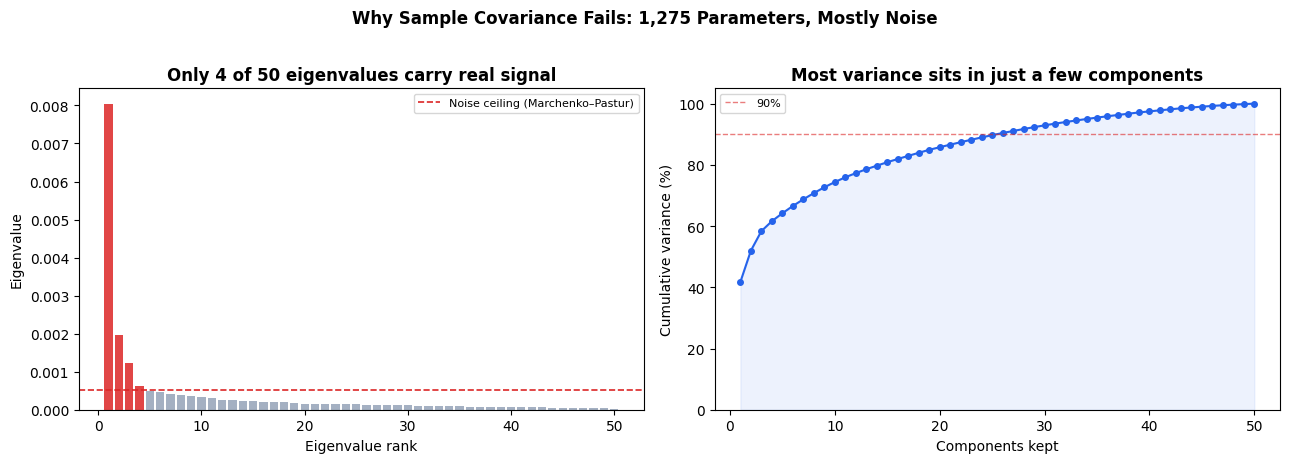

In [2]:
# ── The Baseline Problem: Sample Covariance Is Mostly Noise ─
cov_sample = returns.cov().values
eigvals = np.sort(np.linalg.eigvalsh(cov_sample))[::-1]
q = N / T
sigma2 = np.mean(np.diag(cov_sample))
lam_plus = sigma2 * (1 + np.sqrt(q))**2
n_signal = int(np.sum(eigvals > lam_plus))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

colors = ['#dc2626' if v > lam_plus else '#94a3b8' for v in eigvals]
axes[0].bar(range(1, N+1), eigvals, color=colors, alpha=0.85, width=0.8)
axes[0].axhline(lam_plus, color='#dc2626', ls='--', lw=1.2, label='Noise ceiling (Marchenko–Pastur)')
axes[0].set_xlabel('Eigenvalue rank'); axes[0].set_ylabel('Eigenvalue')
axes[0].set_title(f'Only {n_signal} of {N} eigenvalues carry real signal', fontweight='bold')
axes[0].legend(fontsize=8)

cum_var = np.cumsum(eigvals) / eigvals.sum() * 100
axes[1].plot(range(1, N+1), cum_var, 'o-', color='#2563eb', ms=4, lw=1.5)
axes[1].axhline(90, color='#dc2626', ls='--', lw=1, alpha=0.6, label='90%')
axes[1].fill_between(range(1, N+1), cum_var, alpha=0.08, color='#2563eb')
axes[1].set_xlabel('Components kept'); axes[1].set_ylabel('Cumulative variance (%)')
axes[1].set_title('Most variance sits in just a few components', fontweight='bold')
axes[1].legend(fontsize=8); axes[1].set_ylim(0, 105)

plt.suptitle('Why Sample Covariance Fails: 1,275 Parameters, Mostly Noise',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## How the Methods Differ

Each method makes a different assumption about what should be trusted in the covariance matrix.

**Ledoit-Wolf Shrinkage** blends the sample covariance with a structured target matrix at an analytically chosen weight:
$$\hat{\Sigma}_{LW} = \alpha^* F + (1-\alpha^*) S$$

**RMT Eigenvalue Cleaning** keeps signal-dominant eigencomponents and shrinks the noisy tail of the spectrum:
$$\hat{\Sigma}_{RMT} = \sum_{i\in\text{signal}} \lambda_i v_i v_i^\top + \bar{\lambda}_{\text{noise}} I_{\text{noise}}$$

**Fama-French 3-Factor Covariance** imposes factor structure and estimates idiosyncratic residual risk separately:
$$\hat{\Sigma}_{FF3} = B\,\Sigma_f\,B^\top + D$$

**DCC-GARCH Dynamic Covariance** updates volatility and correlation through time:
$$H_t = D_t\,R_t\,D_t$$

The tradeoff is straightforward: stronger structure reduces estimation noise, while higher flexibility can capture regime shifts but risks overfitting recent moves.


In [3]:
# ── M1: Ledoit-Wolf Shrinkage ──────────────────────────────
from sklearn.covariance import LedoitWolf
def estimate_lw(returns_df):
    """Shrink sample cov toward constant-correlation target. See M1 for full derivation."""
    return LedoitWolf().fit(returns_df.values).covariance_

# ── M2: RMT Eigenvalue Cleaning ────────────────────────────
def estimate_rmt(returns_df):
    """Replace noise eigenvalues (below Marchenko-Pastur bound) with their mean."""
    S = returns_df.cov().values
    T_, N_ = returns_df.shape
    q = N_ / T_
    sigma2 = np.mean(np.diag(S))
    lam_plus = sigma2 * (1 + np.sqrt(q))**2
    eigvals, eigvecs = np.linalg.eigh(S)
    noise = eigvals <= lam_plus
    cleaned = np.where(noise, eigvals[noise].mean() if noise.any() else sigma2, eigvals)
    return eigvecs @ np.diag(cleaned) @ eigvecs.T

# ── M3: Fama-French 3-Factor Model ─────────────────────────
def estimate_ff3(returns_df):
    """Σ = B Σ_f B' + D using market, SMB, HML factors. See M3 for full derivation."""
    dates = returns_df.index.intersection(ff.index)
    excess = returns_df.loc[dates].subtract(rf.loc[dates], axis=0)
    F = ff.loc[dates, ['Mkt-RF','SMB','HML']].values
    X = np.column_stack([np.ones(len(dates)), F])
    n = excess.shape[1]
    B, resid_var = np.zeros((n,3)), np.zeros(n)
    for i, col in enumerate(excess.columns):
        coefs = np.linalg.lstsq(X, excess[col].values, rcond=None)[0]
        B[i] = coefs[1:]
        resid_var[i] = np.var(excess[col].values - X @ coefs, ddof=1)
    return B @ np.cov(F, rowvar=False) @ B.T + np.diag(resid_var)

# ── M4: DCC-GARCH (EWMA proxy) ─────────────────────────────
def estimate_dcc(returns_df, lam=0.94):
    """Exponentially-weighted covariance — captures time-varying risk (see M4 for full DCC-GARCH)."""
    X = returns_df.values - returns_df.values.mean(axis=0)
    C = np.cov(X[:30].T) if len(X) >= 30 else np.eye(X.shape[1]) * 1e-4
    for t in range(len(X)):
        C = lam * C + (1-lam) * np.outer(X[t], X[t])
    return C + np.eye(X.shape[1]) * 1e-8

print("All four estimators defined ✓")

All four estimators defined ✓


In [4]:
def min_variance_portfolio(cov):
    n = cov.shape[0]; w0 = np.ones(n)/n
    res = minimize(lambda w: w @ cov @ w, w0, method='SLSQP',
                   bounds=[(0,1)]*n,
                   constraints=[{'type':'eq','fun':lambda w: w.sum()-1}],
                   options={'ftol':1e-12,'maxiter':1000})
    return res.x if res.success else w0

LOOKBACK, REBAL, MIN_HIST = 252, 21, 252
dates = returns.index[MIN_HIST:]
n = returns.shape[1]
strategies = ['Equal Weight Benchmark','Sample Covariance','Ledoit-Wolf Shrinkage','RMT Eigenvalue Cleaning','Fama-French 3-Factor Covariance','DCC-GARCH Dynamic Covariance']
pv  = {k: [1.0] for k in strategies}
cw  = {k: np.ones(n)/n for k in strategies}
w_last = {}

print("Running backtest...", end='', flush=True)
for i, date in enumerate(dates):
    idx = returns.index.get_loc(date)
    if i % REBAL == 0:
        win = returns.iloc[idx-LOOKBACK:idx]
        cw['Equal Weight Benchmark'] = np.ones(n)/n
        cw['Sample Covariance'] = min_variance_portfolio(win.cov().values)
        cw['Ledoit-Wolf Shrinkage'] = min_variance_portfolio(estimate_lw(win))
        cw['RMT Eigenvalue Cleaning'] = min_variance_portfolio(estimate_rmt(win))
        cw['Fama-French 3-Factor Covariance'] = min_variance_portfolio(estimate_ff3(win))
        cw['DCC-GARCH Dynamic Covariance'] = min_variance_portfolio(estimate_dcc(win))
    day_ret = returns.iloc[idx].values
    for k in strategies:
        pv[k].append(pv[k][-1] * (1 + cw[k] @ day_ret))
w_last = {k: cw[k].copy() for k in strategies}

portfolio_df = pd.DataFrame(pv, index=[dates[0]-pd.Timedelta(days=1)]+list(dates))
print(f" ✓  ({len(dates)} days, {len(dates)//REBAL} rebalances)")

Running backtest...

 ✓  (1507 days, 71 rebalances)


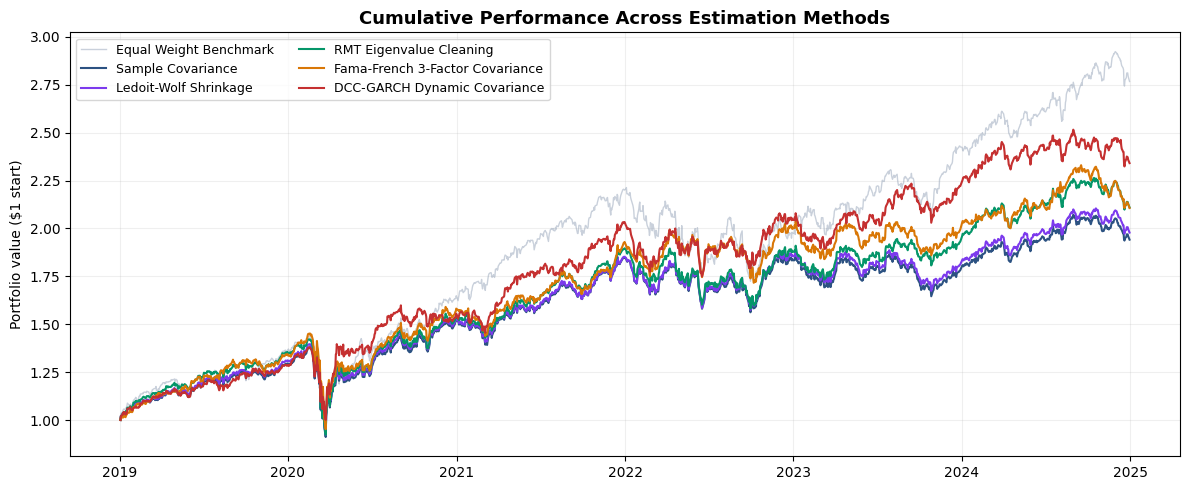

,Ann. Return (%),Ann. Vol (%),Sharpe,Max DD (%)
Equal Weight Benchmark,19.000000,19.860000,0.960000,-34.270000
Sample Covariance,12.570000,17.190000,0.730000,-33.960000
Ledoit-Wolf Shrinkage,12.880000,17.110000,0.750000,-33.970000
RMT Eigenvalue Cleaning,13.990000,17.320000,0.810000,-35.080000
Fama-French 3-Factor Covariance,14.020000,17.690000,0.790000,-34.420000
DCC-GARCH Dynamic Covariance,15.690000,17.090000,0.920000,-27.480000


In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
for k in strategies:
    lw = 1.5 if k != 'Equal Weight Benchmark' else 1.0
    al = 1.0 if k != 'Equal Weight Benchmark' else 0.5
    ax.plot(portfolio_df.index, portfolio_df[k], label=k, color=COLORS[k], lw=lw, alpha=al)
ax.set_ylabel('Portfolio value ($1 start)')
ax.set_title('Cumulative Performance Across Estimation Methods', fontweight='bold', fontsize=13)
ax.legend(ncol=2, fontsize=9, loc='upper left')
ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

def metrics(v):
    r = v.pct_change().dropna()
    ar, av = r.mean()*252, r.std()*np.sqrt(252)
    return {'Ann. Return (%)': ar*100, 'Ann. Vol (%)': av*100,
            'Sharpe': ar/av if av>0 else 0,
            'Max DD (%)': ((v/v.cummax())-1).min()*100}

display(pd.DataFrame({k: metrics(portfolio_df[k]) for k in strategies}).T.round(2)
        .style.background_gradient(subset=['Sharpe'], cmap='RdYlGn')
              .background_gradient(subset=['Ann. Vol (%)'], cmap='YlOrRd_r'))

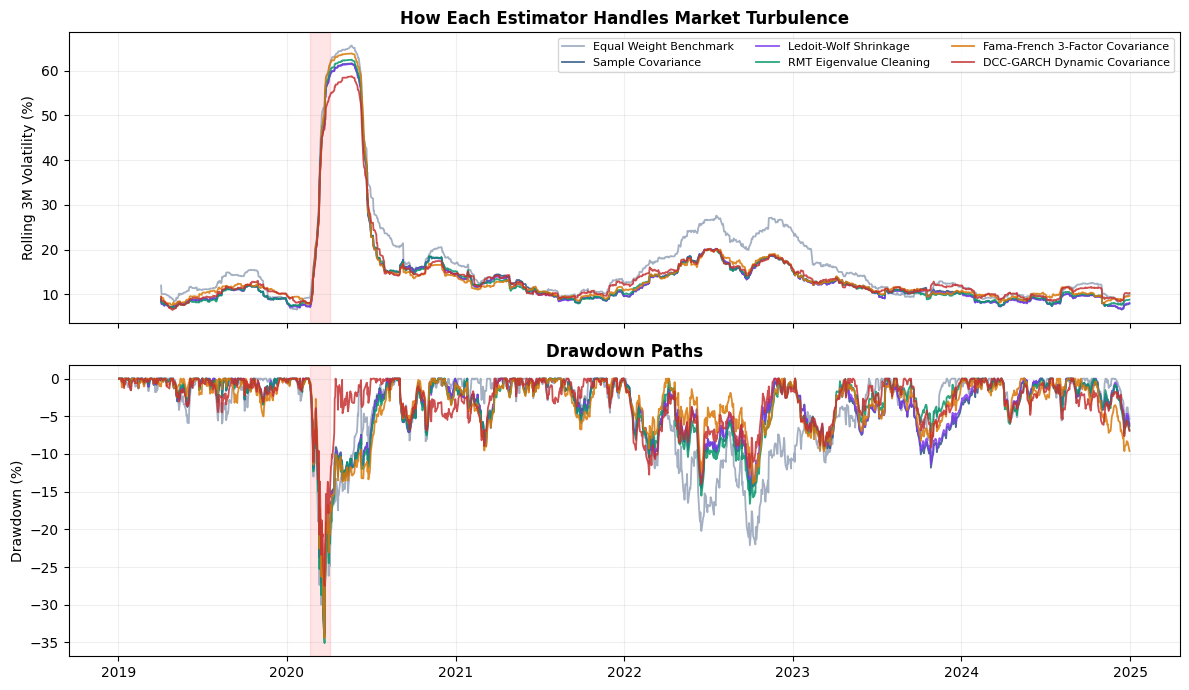

In [6]:
# ── Risk Over Time ─────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for k in strategies:
    vol = portfolio_df[k].pct_change().rolling(63).std() * np.sqrt(252) * 100
    axes[0].plot(portfolio_df.index, vol, color=COLORS[k], lw=1.3, alpha=0.85, label=k)
axes[0].axvspan(pd.Timestamp('2020-02-20'), pd.Timestamp('2020-04-03'),
                alpha=0.1, color='red')
axes[0].annotate('COVID crash', xy=(pd.Timestamp('2020-03-10'), 0),
                 xytext=(pd.Timestamp('2020-06-01'), axes[0].get_ylim()[1]*0.85 if axes[0].get_ylim()[1] > 0 else 40),
                 fontsize=8, color='#dc2626')
axes[0].set_ylabel('Rolling 3M Volatility (%)')
axes[0].set_title('How Each Estimator Handles Market Turbulence', fontweight='bold')
axes[0].legend(ncol=3, fontsize=8); axes[0].grid(True, alpha=0.2)

for k in strategies:
    dd = (portfolio_df[k] / portfolio_df[k].cummax() - 1) * 100
    axes[1].plot(portfolio_df.index, dd, color=COLORS[k], lw=1.3, alpha=0.85)
axes[1].axvspan(pd.Timestamp('2020-02-20'), pd.Timestamp('2020-04-03'),
                alpha=0.1, color='red')
axes[1].set_ylabel('Drawdown (%)')
axes[1].set_title('Drawdown Paths', fontweight='bold')
axes[1].grid(True, alpha=0.2)

plt.tight_layout(); plt.show()

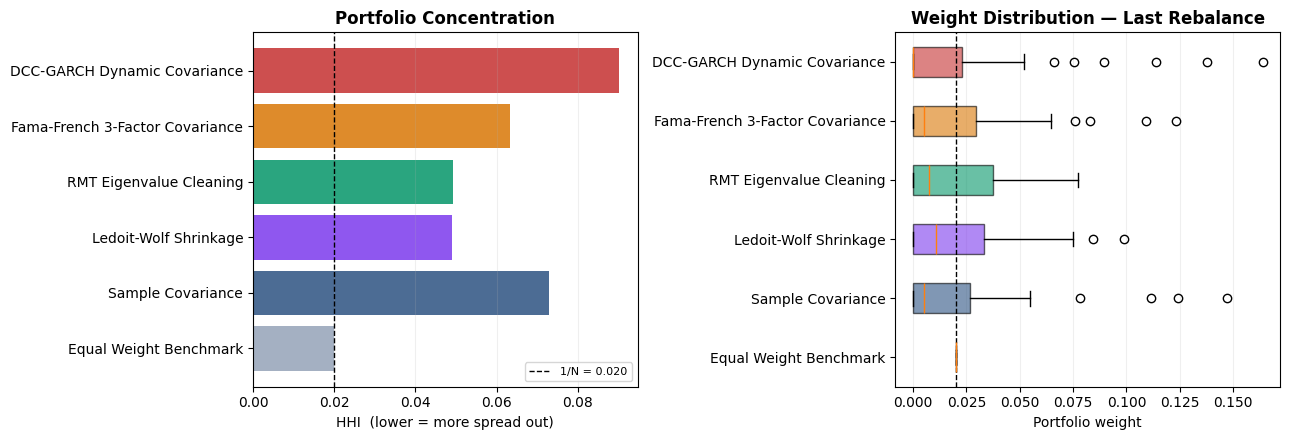

HHI (1/N baseline = 0.0200):
  Equal Weight Benchmark  0.0200  (50/50 positions > 1%)
  Sample Covariance  0.0728  (23/50 positions > 1%)
  Ledoit-Wolf Shrinkage  0.0490  (26/50 positions > 1%)
  RMT Eigenvalue Cleaning  0.0494  (24/50 positions > 1%)
  Fama-French 3-Factor Covariance  0.0633  (21/50 positions > 1%)
  DCC-GARCH Dynamic Covariance  0.0902  (17/50 positions > 1%)


In [7]:
# ── Portfolio Concentration at Last Rebalance ──────────────
hhi = {k: np.sum(w_last[k]**2) for k in strategies}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].barh(list(hhi.keys()), list(hhi.values()),
             color=[COLORS[k] for k in strategies], alpha=0.85)
axes[0].axvline(1/N, color='black', ls='--', lw=1, label=f'1/N = {1/N:.3f}')
axes[0].set_xlabel('HHI  (lower = more spread out)')
axes[0].set_title('Portfolio Concentration', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(True, axis='x', alpha=0.2)

bp = axes[1].boxplot([w_last[k] for k in strategies], vert=False,
                     labels=strategies, patch_artist=True, widths=0.5)
for patch, k in zip(bp['boxes'], strategies):
    patch.set_facecolor(COLORS[k]); patch.set_alpha(0.6)
axes[1].axvline(1/N, color='black', ls='--', lw=1)
axes[1].set_xlabel('Portfolio weight')
axes[1].set_title('Weight Distribution — Last Rebalance', fontweight='bold')
axes[1].grid(True, axis='x', alpha=0.2)

plt.tight_layout(); plt.show()

print("HHI (1/N baseline = {:.4f}):".format(1/N))
for k in strategies:
    print(f"  {k:16s}  {hhi[k]:.4f}  ({np.sum(w_last[k]>0.01)}/{N} positions > 1%)")

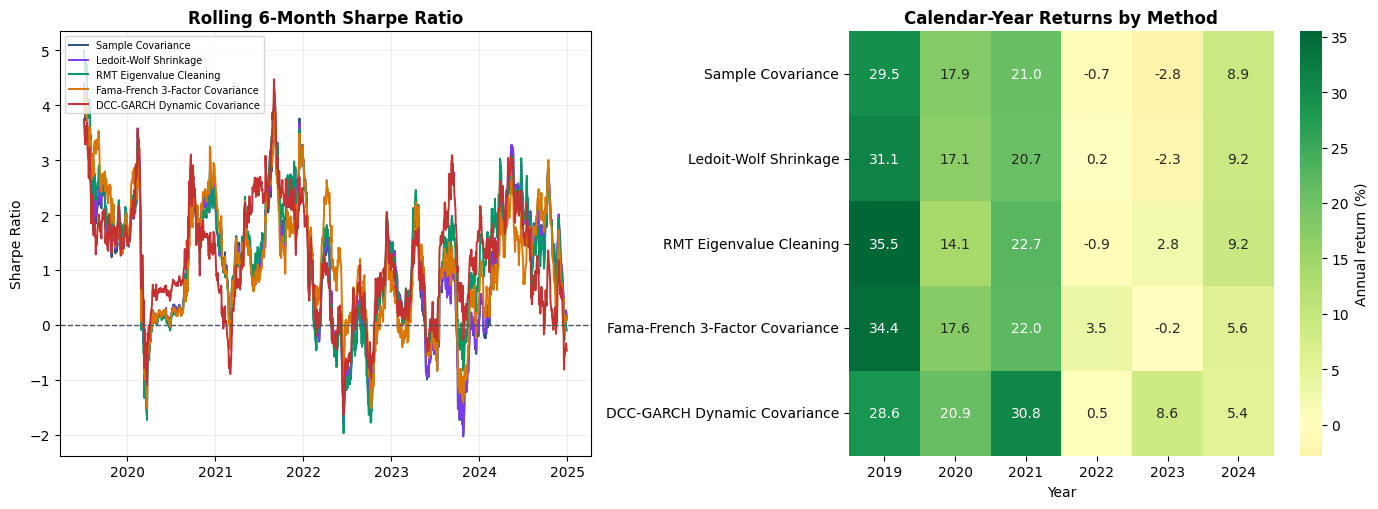

In [8]:
## Additional Diagnostics

ret_df = portfolio_df.pct_change().dropna()
focus = [
    'Sample Covariance',
    'Ledoit-Wolf Shrinkage',
    'RMT Eigenvalue Cleaning',
    'Fama-French 3-Factor Covariance',
    'DCC-GARCH Dynamic Covariance',
]

rolling_sharpe = (ret_df[focus].rolling(126).mean() * 252) / (ret_df[focus].rolling(126).std() * np.sqrt(252))
annual_returns = ((1 + ret_df[focus]).groupby(ret_df.index.year).prod() - 1) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
for k in focus:
    axes[0].plot(rolling_sharpe.index, rolling_sharpe[k], color=COLORS[k], lw=1.4, label=k)
axes[0].axhline(0, color='#475569', ls='--', lw=1)
axes[0].set_title('Rolling 6-Month Sharpe Ratio', fontweight='bold')
axes[0].set_ylabel('Sharpe Ratio')
axes[0].grid(True, alpha=0.2)
axes[0].legend(fontsize=7, loc='upper left')

sns.heatmap(annual_returns.T, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            cbar_kws={'label': 'Annual return (%)'}, ax=axes[1])
axes[1].set_title('Calendar-Year Returns by Method', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


## What the Evidence Says

**All regularized estimators improve risk control versus raw sample covariance.** That result is consistent across cumulative performance, rolling volatility, drawdowns, and concentration diagnostics.

**Ledoit-Wolf and RMT are the most robust defaults in this dataset.** They reduce variance from estimation noise without imposing strong economic structure.

**Fama-French structure adds interpretability and diversification discipline.** It performs best when factor assumptions are aligned with the assets under study.

**DCC-GARCH adds regime sensitivity.** It reacts faster during stress periods, but that flexibility requires tighter monitoring of model stability.

Method choice should match the dominant risk in your use case: static estimation noise, structural misspecification, or time-varying regime shifts.


Related modules: [Ledoit-Wolf](M1_ledoit_wolf.ipynb) | [RMT Cleaning](M2_rmt_cleaning.ipynb) | [Fama-French](M3_factor_models.ipynb) | [DCC-GARCH](M4_dcc_garch.ipynb)
